<a href="https://colab.research.google.com/github/aarushi795/Human-Activity-Recognition-using-IMU-Sensor-Data/blob/main/project_file.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **DATA VISUALISATION OF SENSOR DATA**


# DATA SET 1  
Data obtained from Wireless Sensor Data Mining
(WISDM) Lab.  
The data includes statistical features like mean, standard deviation, skewness, kurtosis, etc., across multiple axes (X, Y, Z).  
Total Instances: 5418  
Total Features: 46  
Data Format: ARFF



In [ ]:
from google.colab import drive
drive.mount('/content/drive')
file_path = '/content/drive/MyDrive/Internship/WISDM_ar_latest/WISDM_ar_v1.1/WISDM_ar_v1.1_transformed.arff'

with open(file_path, 'r') as f:
    for _ in range(20):
        print(f.readline().rstrip())


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
@relation activity_recognition_labeled

@attribute "UNIQUE_ID" numeric
@attribute "user" {"33" , "17", "29", "13" , "20" , "27" , "6" , "15" , "32" , "36" , "18" , "35" , "11" , "16" , "5", "10" , "28" , "26" , "14" , "24" , "12" , "23" , "4" , "30" , "34" , "8" , "31" , "21" , "3" , "22" , "1" , "25" , "9" , "2" , "7" , "19"}
@attribute "X0" numeric
@attribute "X1" numeric
@attribute "X2" numeric
@attribute "X3" numeric
@attribute "X4" numeric
@attribute "X5" numeric
@attribute "X6" numeric
@attribute "X7" numeric
@attribute "X8" numeric
@attribute "X9" numeric
@attribute "Y0" numeric
@attribute "Y1" numeric
@attribute "Y2" numeric
@attribute "Y3" numeric
@attribute "Y4" numeric
@attribute "Y5" numeric


In [ ]:
import re

input_path = '/content/drive/MyDrive/Internship/WISDM_ar_latest/WISDM_ar_v1.1/WISDM_ar_v1.1_transformed.arff'
cleaned_path = '/content/WISDM_ar_v1.1_transformed_clean.arff'

with open(input_path, 'r') as f:
    lines = f.readlines()

clean_lines = []

pattern = re.compile(r'(@attribute\s+"?[^"]+"?\s*)\{([^}]+)\}', re.IGNORECASE)

for line in lines:
    # Special fix for line starting with '@attribute class'
    if line.lower().startswith('@attribute class'):
        clean_line = '@attribute class {Walking,Jogging,Upstairs,Downstairs,Sitting,Standing}\n'
        clean_lines.append(clean_line)
        continue

    match = pattern.match(line)
    if match:
        prefix = match.group(1)
        vals = match.group(2)
        # Remove quotes and spaces from nominal values
        vals_clean = ','.join(v.strip().strip('"') for v in vals.split(','))
        clean_line = f'{prefix}{{{vals_clean}}}\n'
        clean_lines.append(clean_line)
    else:
        clean_lines.append(line)

with open(cleaned_path, 'w') as f:
    f.writelines(clean_lines)

from scipy.io import arff
import pandas as pd

data, meta = arff.loadarff(cleaned_path)
df = pd.DataFrame(data)
df.head()

,"""UNIQUE_ID""","""user""","""X0""","""X1""","""X2""","""X3""","""X4""","""X5""","""X6""","""X7""",...,"""YPEAK""","""ZPEAK""","""XABSOLDEV""","""YABSOLDEV""","""ZABSOLDEV""","""XSTANDDEV""","""YSTANDDEV""","""ZSTANDDEV""","""RESULTANT""",class
0,1.0,b'33',0.04,0.09,0.14,0.12,0.11,0.10,0.08,0.13,...,293.94,1550.00,3.29,7.21,4.00,4.05,8.17,4.05,11.96,b'Jogging'
1,2.0,b'33',0.12,0.12,0.06,0.07,0.11,0.10,0.11,0.09,...,269.44,1233.33,4.23,6.88,4.05,5.43,8.19,5.43,12.05,b'Jogging'
2,3.0,b'33',0.14,0.09,0.11,0.09,0.09,0.11,0.12,0.08,...,248.65,1780.00,4.18,6.89,4.07,5.55,8.19,5.55,11.99,b'Jogging'
3,4.0,b'33',0.06,0.10,0.09,0.09,0.11,0.07,0.12,0.10,...,709.09,1380.00,2.26,4.13,2.49,2.87,4.95,2.87,10.69,b'Walking'
4,5.0,b'33',0.12,0.11,0.10,0.08,0.10,0.14,0.10,0.11,...,3300.00,1775.00,2.29,3.94,2.41,3.08,4.64,3.08,10.80,b'Walking'


In [ ]:
df['class'] = df['class'].str.decode('utf-8')
classes = df['class'].unique()
class_dfs = {cls: df[df['class'] == cls] for cls in classes}
walking_df = class_dfs['Walking']
print(walking_df.head())
df['class'] = df['class'].str.decode('utf-8')
df = df.dropna(subset=['class'])

    "UNIQUE_ID" "user"  "X0"  "X1"  "X2"  "X3"  "X4"  "X5"  "X6"  "X7"  ...  \
3           4.0  b'33'  0.06  0.10  0.09  0.09  0.11  0.07  0.12  0.10  ...   
4           5.0  b'33'  0.12  0.11  0.10  0.08  0.10  0.14  0.10  0.11  ...   
5           6.0  b'33'  0.09  0.09  0.10  0.12  0.08  0.06  0.09  0.08  ...   
35         36.0  b'33'  0.08  0.08  0.09  0.09  0.10  0.13  0.08  0.15  ...   
36         37.0  b'33'  0.11  0.09  0.13  0.10  0.10  0.07  0.09  0.10  ...   

    "YPEAK"  "ZPEAK"  "XABSOLDEV"  "YABSOLDEV"  "ZABSOLDEV"  "XSTANDDEV"  \
3    709.09   1380.0         2.26         4.13         2.49         2.87   
4   3300.00   1775.0         2.29         3.94         2.41         3.08   
5   1337.50   2675.0         2.00         3.39         1.94         3.13   
35   861.11   1600.0         2.55         4.17         2.27         3.04   
36  1131.25   1650.0         2.64         3.86         2.41         3.12   

    "YSTANDDEV"  "ZSTANDDEV"  "RESULTANT"    class  
3          4.95

**ANOVA** **TEST**

In [ ]:
df = pd.DataFrame(data)
df['class'] = df['class'].apply(lambda x: x.decode('utf-8') if isinstance(x, bytes) else x)


df = df.dropna(subset=['class'])

df = df.dropna()


In [ ]:
from scipy.stats import f_oneway

anova_results = []

for feature in df.select_dtypes(include='number').columns.difference(['UNIQUE_ID']):
    groups = [
        df[df['class'] == label][feature]
        for label in df['class'].unique()
        if len(df[df['class'] == label][feature]) > 1
    ]
    if len(groups) >= 2:
        f_stat, p_val = f_oneway(*groups)
        anova_results.append((feature, f_stat, p_val))

anova_df = pd.DataFrame(anova_results, columns=['Feature', 'F-statistic', 'p-value'])
anova_df = anova_df.sort_values(by='F-statistic', ascending=False)
print(anova_df)


/usr/local/lib/python3.11/dist-packages/scipy/stats/_axis_nan_policy.py:579: ConstantInputWarning: Each of the input arrays is constant; the F statistic is not defined or infinite
  res = hypotest_fun_out(*samples, **kwds)


        Feature  F-statistic        p-value
26  "YABSOLDEV"  2856.459644   0.000000e+00
29  "YSTANDDEV"  2637.878394   0.000000e+00
40  "ZABSOLDEV"  1241.224400   0.000000e+00
0   "RESULTANT"   660.341559   0.000000e+00
41       "ZAVG"   616.748160   0.000000e+00
15  "XSTANDDEV"   581.382132   0.000000e+00
43  "ZSTANDDEV"   581.382132   0.000000e+00
12  "XABSOLDEV"   473.128741   0.000000e+00
27       "YAVG"   228.027607  1.332043e-219
25         "Y9"   162.612969  1.785694e-160
42      "ZPEAK"   117.622901  7.099022e-118
28      "YPEAK"   115.274135  1.320252e-115
32         "Z2"   106.008686  1.312749e-106
18         "Y2"    80.821958   8.741345e-82
5          "X3"    76.163054   3.907196e-77
21         "Y5"    75.557138   1.577602e-76
14      "XPEAK"    69.091781   4.838610e-70
3          "X1"    63.617878   1.598495e-64
11         "X9"    61.172637   4.753153e-62
36         "Z6"    45.190449   9.063872e-46
16         "Y0"    41.226238   1.057399e-41
34         "Z4"    40.197382   1

Features having very high F-statistics and p-values close to zero, indicate strong statistical evidence that their values differ across activity classes:

"YABSOLDEV" (F ≈ 2856)

"YSTANDDEV" (F ≈ 2637)

"ZABSOLDEV" (F ≈ 1241)

"RESULTANT" (F ≈ 660)

"ZAVG" (F ≈ 616)

"XSTANDDEV", "ZSTANDDEV", "XABSOLDEV"

Inference: These features are highly effective in differentiating between human activities and should be prioritized for model training or dimensionality reduction.

In [ ]:
df.shape

(4944, 46)

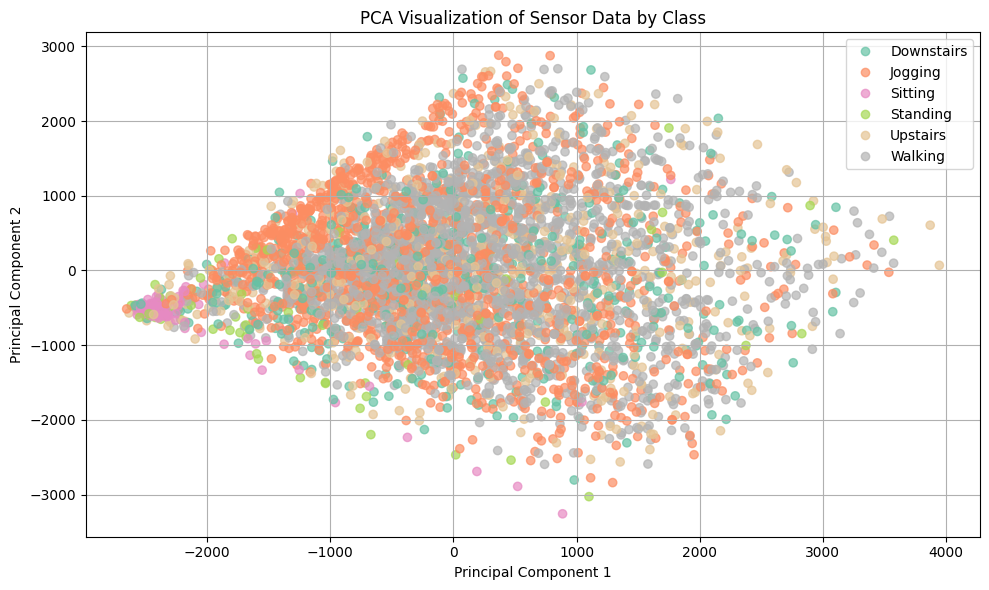

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import LabelEncoder


non_feature_cols = ['"UNIQUE_ID"', '"user"', 'class']
features = df.drop(columns=non_feature_cols)
features = features.apply(pd.to_numeric, errors='coerce')
features = features.dropna(axis=1)
labels = df["class"]
le = LabelEncoder()
label_encoded = le.fit_transform(labels)
pca = PCA(n_components=2)
components = pca.fit_transform(features)

plt.figure(figsize=(10, 6))
scatter = plt.scatter(components[:, 0], components[:, 1], c=label_encoded, cmap="Set2", alpha=0.7)
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("PCA Visualization of Sensor Data by Class")
legend_handles, _ = scatter.legend_elements()
plt.legend(legend_handles, le.classes_.tolist())
plt.grid(True)
plt.tight_layout()
plt.show()


**PCA Visualization of Sensor Data by Activity Class**

The above scatter plot presents a Principal Component Analysis (PCA)-based 2D visualization of the high-dimensional sensor dataset used for human activity recognition.

**Axes:**

Principal Component 1 and Principal Component 2 represent the top two directions (linear combinations of original features) that capture the maximum variance in the dataset.

These components help reduce dimensionality while preserving the essential structure of the data.

**Interpretation:**

1.Jogging data points (orange) form a distinct and dense cluster, suggesting high separability from other classes.

2.Sitting and Standing (pink and lime green) show partial overlap but still exhibit some degree of separability.

3.Walking, Downstairs, and Upstairs have overlapping distributions, which may pose challenges for classification models.

4.The distribution of points reflects the complexity and similarity of movement patterns between certain activities.



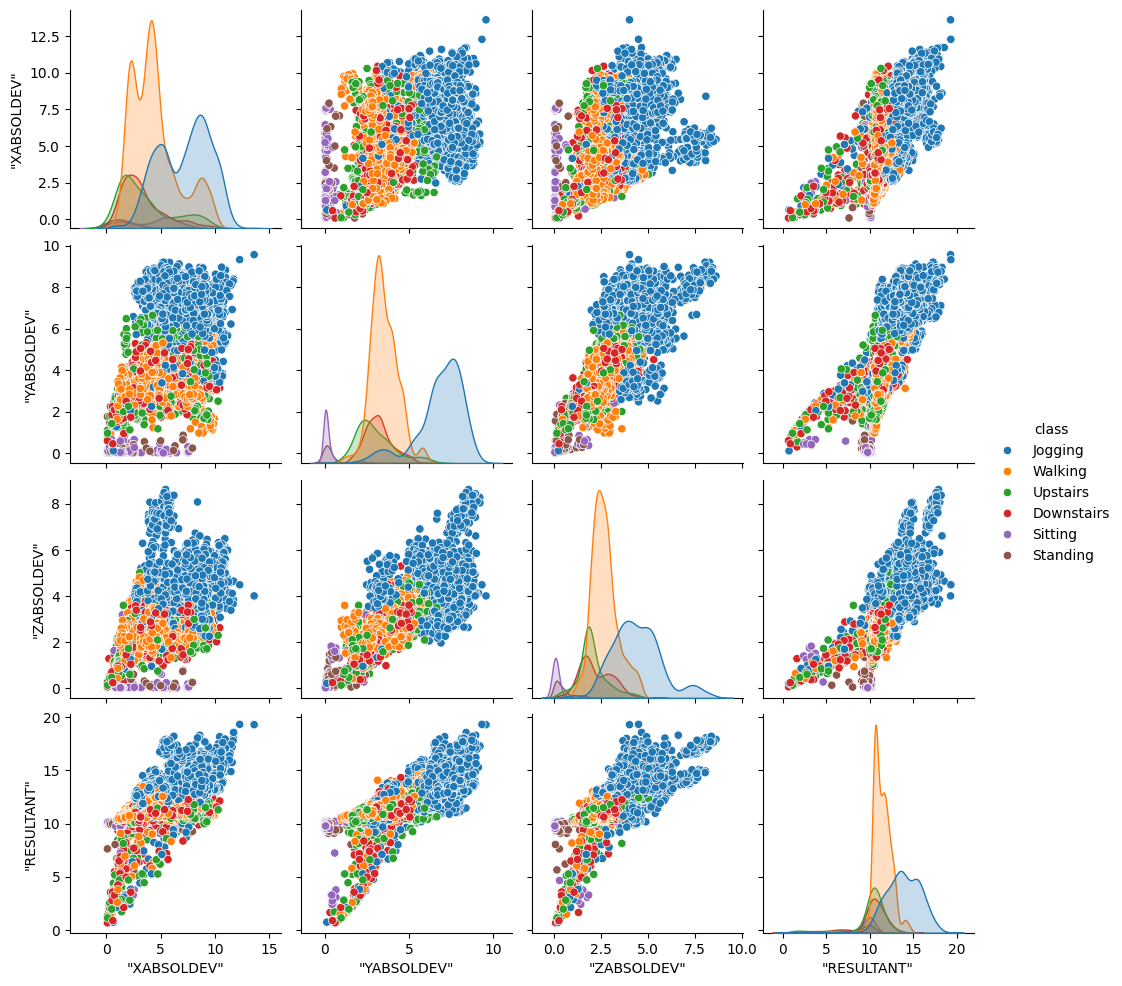

In [ ]:
import seaborn as sns
sns.pairplot(df, hue='class', vars=['"XABSOLDEV"', '"YABSOLDEV"', '"ZABSOLDEV"', '"RESULTANT"'])

This pairplot reveals several key patterns in how different activities manifest across motion features:

1.Jogging (blue) consistently shows high values across all features (XABSOLDEV, YABSOLDEV, ZABSOLDEV, and RESULTANT), forming dense clusters in the upper regions of the plots. This reflects high-intensity, multidirectional motion—typical of vigorous activity.

2.Walking (orange) also shows elevated feature values but is more spread out and overlaps partially with other classes like Upstairs (green) and Downstairs (red). This suggests that while walking is more active than static classes, it's not as intense or distinct as jogging.

3.Sitting (purple) and Standing (brown) are tightly clustered near the origin with low absolute deviations and resultant values, indicating very little movement. Their close proximity makes them harder to distinguish from one another based on these features alone.

4.Upstairs and Downstairs display intermediate patterns, overlapping with both Walking and each other, indicating similarity in motion profiles but with subtle differences in magnitude or directionality.

5.Overall, the plot highlights that Jogging is clearly separable, while static and transitional activities (Sitting, Standing, Upstairs, Downstairs) exhibit considerable overlap, posing a greater challenge for classification. The strong linear trends between axes also suggest feature redundancy, which PCA or feature selection methods can help address.

<Axes: xlabel='class', ylabel='"RESULTANT"'>

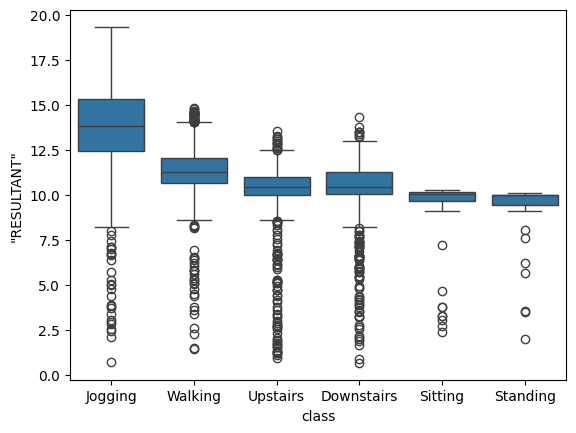

In [ ]:
sns.boxplot(x='class', y='"RESULTANT"', data=df)

This box plot illustrates the distribution of the "RESULTANT" feature—a composite measure of overall motion magnitude—across different activity classes.

Key Interpretations:  
1.Jogging has the highest median and widest range of resultant values, indicating intense and highly variable movement. Its interquartile range (IQR) and whiskers extend significantly higher than all other activities, and many outliers also reflect bursts of high activity.

2.Walking, Upstairs, and Downstairs show similar median values, with moderate variability. Their distributions overlap slightly, suggesting similar movement intensities, but Walking tends to have a slightly higher median than the other two.

3.Sitting and Standing exhibit the lowest median resultant values and the smallest IQR, confirming that these are the least active states with very little motion. The presence of some outliers suggests occasional movement during these static activities, but overall variability is minimal.

# DATA SET 2
The MHEALTH (Mobile HEALTH) dataset comprises body motion and vital signs recordings for ten volunteers of diverse profile while performing several physical activities. Sensors placed on the subject's chest, right wrist and left ankle are used to measure the motion experienced by diverse body parts, namely, acceleration, rate of turn and magnetic field orientation. The sensor positioned on the chest also provides 2-lead ECG measurements, which can be potentially used for basic heart monitoring, checking for various arrhythmias or looking at the effects of exercise on the ECG.  
Activities: 12 (1: "Standing still",
    2: "Sitting and relaxing",
    3: "Lying down",
    4: "Walking",
    5: "Climbing stairs",
    6: "Waist bends forward",
    7: "Frontal elevation of arms",
    8: "Knees bending (crouching)",
    9: "Cycling",
    10: "Jogging",
    11: "Running",
    12: "Jump front & back")  
Sensor devices:3  
Subjects: 10  
Instances:
120

In [ ]:
import os

folder_path = '/content/drive/MyDrive/mhealth+dataset'
all_files = os.listdir(folder_path)
print(all_files)

['MHEALTHDATASET']


In [ ]:
import os

folder_path = '/content/drive/My Drive/mhealth+dataset/MHEALTHDATASET'
all_files = os.listdir(folder_path)


log_files = [f for f in all_files if f.endswith('.log')]
print(f"Found {len(log_files)} log files.")


log_contents = {}

for filename in log_files:
    file_path = os.path.join(folder_path, filename)
    with open(file_path, 'r') as file:
        content = file.read()
        log_contents[filename] = content


some_file = log_files[0]
print(f"Content preview of {some_file}:")
print(log_contents[some_file][:500])


Found 10 log files.
Content preview of mHealth_subject1.log:
-9.8184	0.009971	0.29563	0.0041863	0.0041863	2.1849	-9.6967	0.63077	0.1039	-0.84053	-0.68762	-0.37	-0.36327	0.29963	-8.6499	-4.5781	0.18776	-0.44902	-1.0103	0.034483	-2.35	-1.6102	-0.030899	0
-9.8489	0.52404	0.37348	0.0041863	0.016745	2.3876	-9.508	0.68389	0.085343	-0.83865	-0.68369	-0.19799	-0.18151	0.58298	-8.6275	-4.3198	0.023595	-0.44902	-1.0103	0.034483	-2.1632	-0.88254	0.32657	0
-9.6602	0.18185	0.43742	0.016745	0.037677	2.4086	-9.5674	0.68113	0.085343	-0.83865	-0.68369	-0.37417	0.18723	0.4


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import os
import glob
import re
import pandas as pd


folder_path = '/content/drive/My Drive/mhealth+dataset/MHEALTHDATASET'


columns = [
    "acc_x", "acc_y", "acc_z",
    "ecg_1", "ecg_2",
    "emg_1", "emg_2", "emg_3",
    "gyro_x", "gyro_y", "gyro_z",
    "magneto_x", "magneto_y", "magneto_z",
    "class"
]


activity_map = {
    1: "Standing still",
    2: "Sitting and relaxing",
    3: "Lying down",
    4: "Walking",
    5: "Climbing stairs",
    6: "Waist bends forward",
    7: "Frontal elevation of arms",
    8: "Knees bending (crouching)",
    9: "Cycling",
    10: "Jogging",
    11: "Running",
    12: "Jump front & back"
}


log_pattern = os.path.join(folder_path, "mHealth_subject*.log")
log_files = sorted(glob.glob(log_pattern))

print(f"Found {len(log_files)} log files.")


dataframes = []

for filepath in log_files:

    match = re.search(r"subject(\d+)", filepath)
    if match:
        subject_id = int(match.group(1))


        df = pd.read_csv(filepath, sep=r"\s+", header=None, names=columns)


        df["subject_id"] = subject_id


        df["class_name"] = df["class"].map(activity_map)

        dataframes.append(df)


final_df = pd.concat(dataframes, ignore_index=True)


print(final_df.head())
print(final_df["class_name"].value_counts())


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Found 10 log files.
     acc_x    acc_y     acc_z    ecg_1    ecg_2   emg_1   emg_2     emg_3  \
0 -0.84053 -0.68762 -0.370000 -0.36327  0.29963 -8.6499 -4.5781  0.187760   
1 -0.83865 -0.68369 -0.197990 -0.18151  0.58298 -8.6275 -4.3198  0.023595   
2 -0.83865 -0.68369 -0.374170  0.18723  0.43851 -8.5055 -4.2772  0.275720   
3 -0.83865 -0.68369 -0.017271  0.18366  0.57571 -8.6279 -4.3163  0.367520   
4 -0.83865 -0.68369 -0.374390 -0.54671  0.44586 -8.7008 -4.1459  0.407290   

    gyro_x  gyro_y    gyro_z  magneto_x  magneto_y  magneto_z  class  \
0 -0.44902 -1.0103  0.034483   -2.35000  -1.610200  -0.030899      0   
1 -0.44902 -1.0103  0.034483   -2.16320  -0.882540   0.326570      0   
2 -0.44902 -1.0103  0.034483   -1.61750  -0.165620  -0.030693      0   
3 -0.45686 -1.0082  0.025862   -1.07710   0.006945  -0.382620      0   
4 -0.45686 -1.0082  0.025862

**ANOVA** **TEST**

In [ ]:
from scipy.stats import f_oneway
import pandas as pd

df_clean = final_df.dropna(subset=['class'])

excluded_columns = ['subject_id', 'class', 'class_name']
feature_columns = [col for col in df_clean.columns if col not in excluded_columns]

anova_results = {}

for feature in feature_columns:
    try:
        groups = [df_clean[df_clean['class'] == cls][feature] for cls in df_clean['class'].unique()]
        stat, pval = f_oneway(*groups)
        anova_results[feature] = {'F-statistic': stat, 'p-value': pval}
    except Exception as e:
        anova_results[feature] = {'error': str(e)}

anova_df = pd.DataFrame(anova_results).T
anova_df = anova_df.sort_values(by='F-statistic', ascending=False)

print(anova_df)


            F-statistic       p-value
acc_x      32991.133425  0.000000e+00
gyro_y     17358.828893  0.000000e+00
emg_2      13963.679634  0.000000e+00
gyro_x     12380.625795  0.000000e+00
emg_3      12324.051668  0.000000e+00
emg_1       9619.207079  0.000000e+00
acc_y       8602.884644  0.000000e+00
gyro_z      7712.828969  0.000000e+00
magneto_y    603.779255  0.000000e+00
ecg_2        251.454337  0.000000e+00
ecg_1        241.748841  0.000000e+00
magneto_x    140.244320  0.000000e+00
magneto_z     10.623372  1.981353e-21
acc_z          1.571614  9.198104e-02


ANOVA Test inferences:
Top features for classification: acc_x, gyro_y, emg_2, gyro_x, emg_3, emg_1

Features with moderate usefulness: acc_y, gyro_z, magneto_y, ecg_1, ecg_2

Low or no value: acc_z

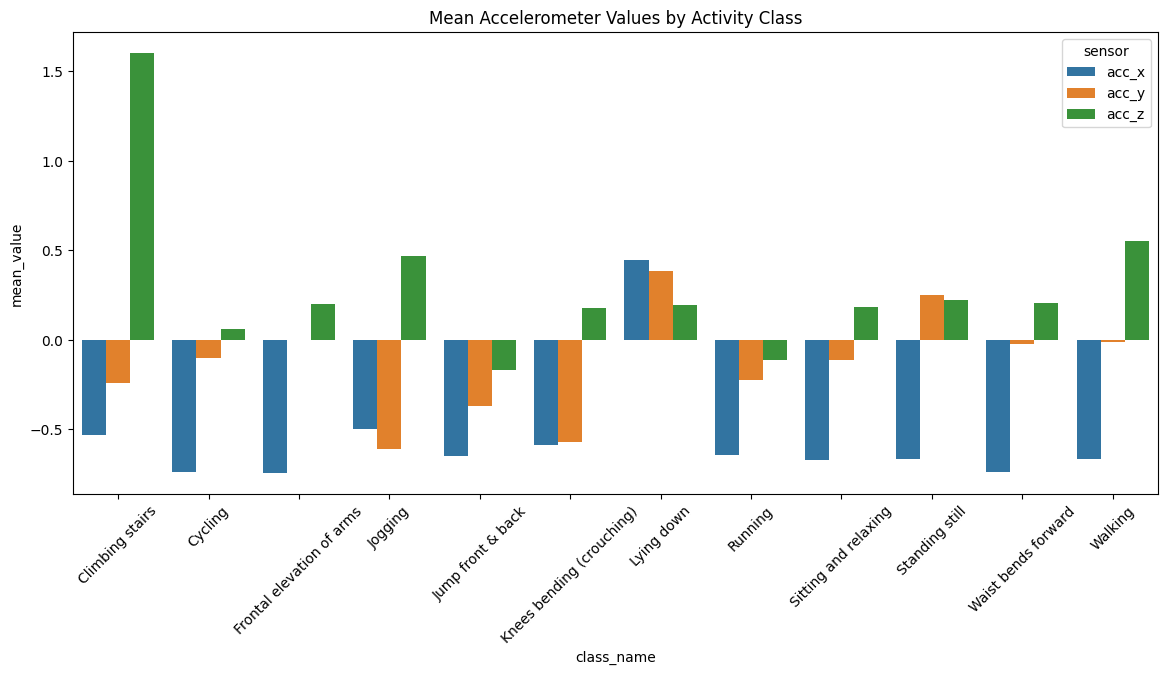

In [ ]:
sensor_cols = ["acc_x", "acc_y", "acc_z"]

mean_sensors = final_df.groupby("class_name")[sensor_cols].mean().reset_index()

mean_sensors = mean_sensors.sort_values("class_name")

mean_sensors_melted = mean_sensors.melt(id_vars="class_name", var_name="sensor", value_name="mean_value")

plt.figure(figsize=(14, 6))
sns.barplot(x="class_name", y="mean_value", hue="sensor", data=mean_sensors_melted)
plt.xticks(rotation=45)
plt.title("Mean Accelerometer Values by Activity Class")
plt.show()

This bar chart compares the mean accelerometer values along the X, Y, and Z axes (acc_x, acc_y, acc_z) for various activity classes. Each activity exhibits a distinct pattern of motion across axes:

1.Climbing stairs shows a very high positive mean on acc_z, likely reflecting strong upward motion against gravity, while acc_x and acc_y are negative.

2.Cycling and Waist bends forward have strongly negative acc_x values, indicating significant horizontal movement or forward tilt.

3.Jogging, Running, and Jump front & back all show similar trends: negative acc_x and acc_y, with acc_z close to zero or slightly positive, suggesting balanced multidirectional activity.

4.Lying down exhibits positive values for all axes, especially acc_x, highlighting a distinct posture with potential static orientation bias.

5.Sitting, Standing still, and Sitting and relaxing all show low mean acceleration values overall, reflecting the low-motion nature of these classes.

6.Walking has a prominent positive acc_z, consistent with repetitive vertical motion during gait, distinguishing it from running and jogging.

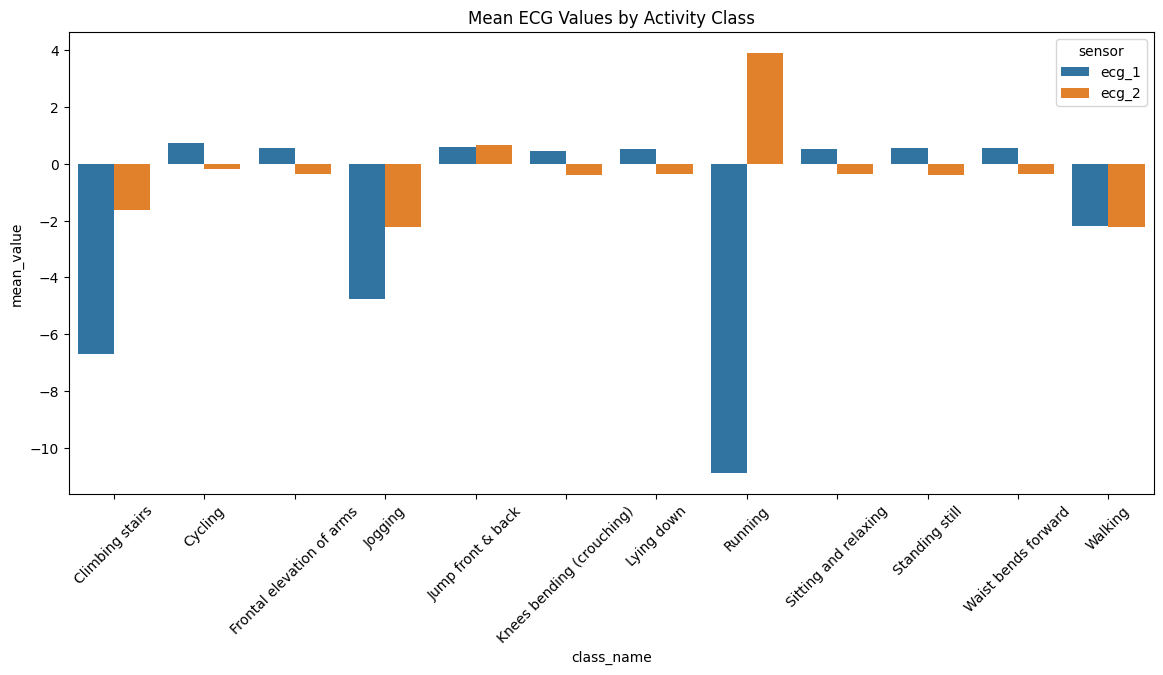

In [ ]:
ecg_cols = ["ecg_1", "ecg_2"]

mean_ecg = final_df.groupby("class_name")[ecg_cols].mean().reset_index()
mean_ecg = mean_ecg.sort_values("class_name")
mean_ecg_melted = mean_ecg.melt(id_vars="class_name", var_name="sensor", value_name="mean_value")

plt.figure(figsize=(14, 6))
sns.barplot(x="class_name", y="mean_value", hue="sensor", data=mean_ecg_melted)
plt.xticks(rotation=45)
plt.title("Mean ECG Values by Activity Class")
plt.show()

Here is the interpretation of the ECG bar chart:

1.Climbing stairs and Jogging show strong negative mean values in ecg_1, indicating elevated cardiovascular activity.

2.Running exhibits the most extreme ECG response, with ecg_1 showing a deep negative mean and ecg_2 showing a high positive mean, possibly reflecting sensor sensitivity or physiological spikes.

3.Cycling, Frontal elevation of arms, and Jump front & back have moderate ECG responses, mostly slightly positive for both sensors.

4.Lying down, Sitting and relaxing, and Standing still show small, consistent ECG means, indicative of rest or low physical exertion.

5.ecg_1 tends to be more negatively skewed for physically intense activities, while ecg_2 shows greater variability depending on the activity.

The plot suggests clear differentiation in heart activity captured by ECG sensors across varying physical tasks.

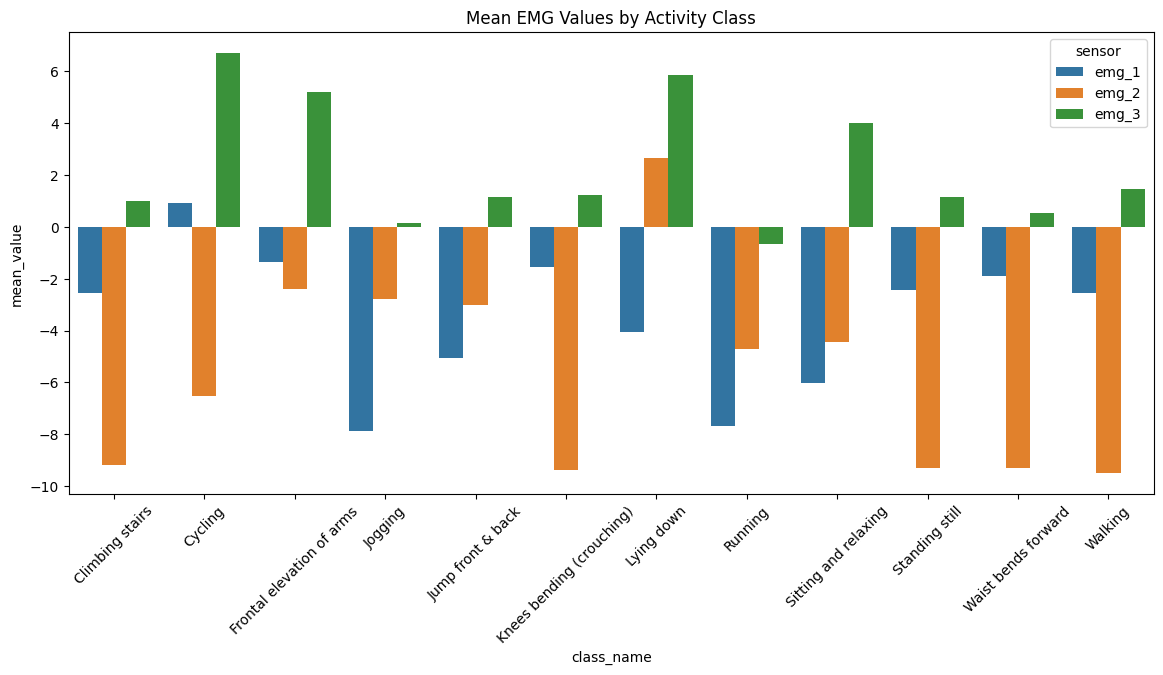

In [ ]:
emg_cols = ["emg_1", "emg_2", "emg_3"]

mean_emg = final_df.groupby("class_name")[emg_cols].mean().reset_index()
mean_emg = mean_emg.sort_values("class_name")
mean_emg_melted = mean_emg.melt(id_vars="class_name", var_name="sensor", value_name="mean_value")

plt.figure(figsize=(14, 6))
sns.barplot(x="class_name", y="mean_value", hue="sensor", data=mean_emg_melted)
plt.xticks(rotation=45)
plt.title("Mean EMG Values by Activity Class")
plt.show()

The bar chart titled "Mean EMG Values by Activity Class" compares the average electromyography (EMG) values from three sensors (emg_1, emg_2, and emg_3) across different physical activities (listed on the x-axis).

Interpretation:

1.Climbing stairs and Jogging show strong negative mean values in emg_1, indicating significant lower-body muscular engagement.

2.Knee's bending (crouching) and Standing still exhibit the most extreme negative responses in emg_2, reflecting high muscle activation or sustained tension in specific muscle groups.

3.Cycling, Frontal elevation of arms, and Lying down show high positive values in emg_3, likely corresponding to postural or upper-body muscle engagement.

4.Lying down, Sitting and relaxing, and Standing still show minimal EMG activity in emg_1 and emg_2, indicating rest or low muscle exertion, with emg_3 contributing more to posture-related activity.

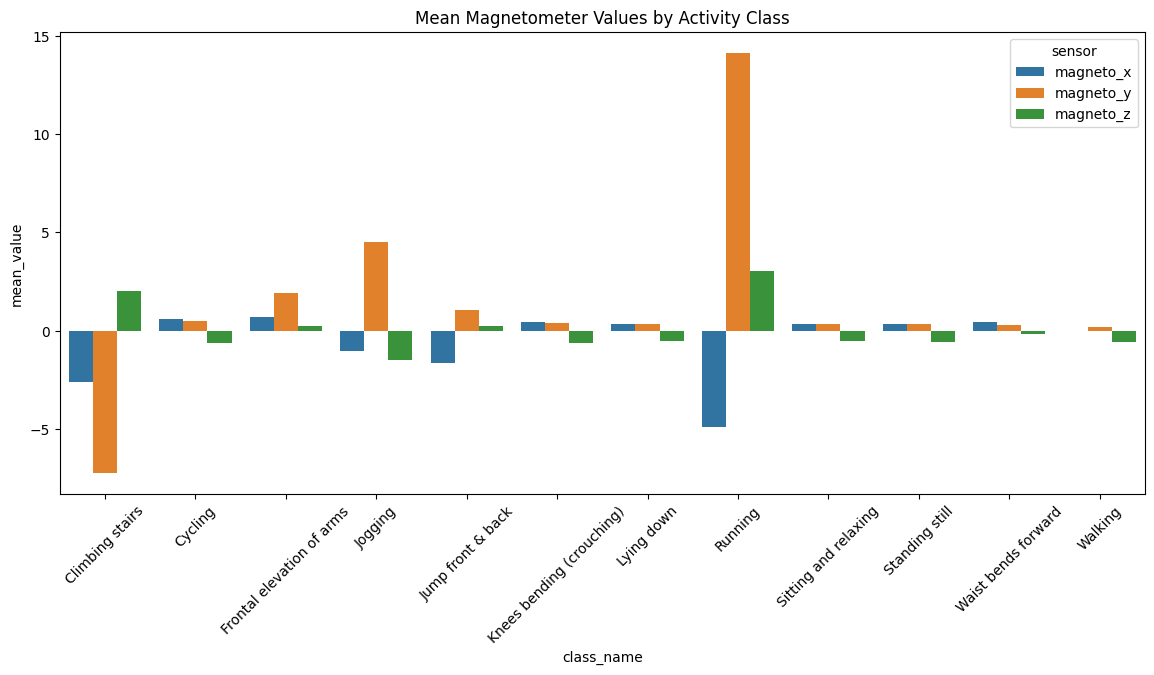

In [ ]:
magneto_cols = ["magneto_x", "magneto_y", "magneto_z"]

mean_magneto = final_df.groupby("class_name")[magneto_cols].mean().reset_index()
mean_magneto = mean_magneto.sort_values("class_name")
mean_magneto_melted = mean_magneto.melt(id_vars="class_name", var_name="sensor", value_name="mean_value")

plt.figure(figsize=(14, 6))
sns.barplot(x="class_name", y="mean_value", hue="sensor", data=mean_magneto_melted)
plt.xticks(rotation=45)
plt.title("Mean Magnetometer Values by Activity Class")
plt.show()

Interpretation of the Mean Magnetometer Values by Activity Class based on the provided bar plot:

1.Running shows the most extreme magnetometer response:

magneto_y is highly positive, suggesting strong motion along the Y-axis (possibly vertical or forward movement).

magneto_x is strongly negative, indicating rapid directional change or arm/leg swing.

magneto_z is moderately positive, reflecting multi-axis movement.

2.Jogging and Frontal elevation of arms also show elevated magneto_y values:

Indicates forward and upward motion, typical of arm swings or moderate aerobic activity.

3.Climbing stairs has:

Negative magneto_x and highly negative magneto_y, suggesting downward and forward/backward motion.

Positive magneto_z, indicating vertical movement due to stair ascent.

4.Jump front & back and Knee's bending (crouching) show small but consistent signals across all axes:

Reflects short, repetitive, multidirectional movement.

5.Cycling and Lying down produce minor variations across all axes:

Suggests low magnetometer activity, with minimal orientation change.

6.Sitting and relaxing, Standing still, Waist bends forward, and Walking have near-zero or slightly negative values:

Indicates minimal magnetic orientation changes, consistent with low-intensity or static postures.

# DATA SET 3
The experiments have been carried out with a group of 30 volunteers within an age bracket of 19-48 years. Each person performed six activities (WALKING, WALKING_UPSTAIRS, WALKING_DOWNSTAIRS, SITTING, STANDING, LAYING) wearing a smartphone (Samsung Galaxy S II) on the waist. Using its embedded accelerometer and gyroscope, we captured 3-axial linear acceleration and 3-axial angular velocity at a constant rate of 50Hz. The experiments have been video-recorded to label the data manually. The obtained dataset has been randomly partitioned into two sets, where 70% of the volunteers was selected for generating the training data and 30% the test data.   
Instances
10299

In [ ]:
from google.colab import drive
import zipfile
 # Mount Google Drive
drive.mount('/content/drive')
 # Define path to the zip file in your Google Drive
zip_path = "/content/drive/My Drive/UCI HAR Dataset.zip"
 # Extract the zip file
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
 zip_ref.extractall("/content/UCI_HAR")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
from google.colab import drive
import zipfile, os

# Mount Google Drive
drive.mount('/content/drive')

# Path to ZIP file in Drive
zip_path = "/content/drive/My Drive/UCI HAR Dataset.zip"

# Extract ZIP to /content/UCI_HAR
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall("/content/UCI_HAR")

# List extracted files to verify
print("Extracted files and folders:")
print(os.listdir("/content/UCI_HAR"))

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Extracted files and folders:
['__MACOSX', 'UCI HAR Dataset']


In [ ]:
 import pandas as pd
 data_dir = "/content/UCI_HAR/UCI HAR Dataset"
 activity_labels = pd.read_csv(
    f"{data_dir}/activity_labels.txt",
    sep='\s+',
    header=None,
    names=["id", "activity"]
 )
 print(activity_labels)


   id            activity
0   1             WALKING
1   2    WALKING_UPSTAIRS
2   3  WALKING_DOWNSTAIRS
3   4             SITTING
4   5            STANDING
5   6              LAYING


In [ ]:

features = pd.read_csv(
    os.path.join(data_dir, "features.txt"),
    sep='\s+', header=None, names=["index", "feature_name"]
)


feature_names = features['feature_name'].tolist()

from collections import Counter
counts = Counter()

unique_feature_names = []
for name in feature_names:
    counts[name] += 1
    if counts[name] > 1:
        unique_name = f"{name}_{counts[name]}"
    else:
        unique_name = name
    unique_feature_names.append(unique_name)

print(f"Total features: {len(feature_names)}, Unique features: {len(unique_feature_names)}")


X_train = pd.read_csv(
    os.path.join(data_dir, "train", "X_train.txt"),
    sep='\s+', header=None, names=unique_feature_names
)
X_test = pd.read_csv(
    os.path.join(data_dir, "test", "X_test.txt"),
    sep='\s+', header=None, names=unique_feature_names
)


Total features: 561, Unique features: 561


In [ ]:
import os
import pandas as pd
from collections import Counter

DATA_DIR = "/content/UCI_HAR/UCI HAR Dataset"

activity_labels = pd.read_csv(os.path.join(DATA_DIR, "activity_labels.txt"), sep='\s+', header=None, names=["id", "activity"])
activity_map = dict(zip(activity_labels.id, activity_labels.activity))

features = pd.read_csv(os.path.join(DATA_DIR, "features.txt"), sep='\s+', header=None, names=["index", "feature_name"])
feature_names = features['feature_name'].tolist()

counts = Counter()
unique_feature_names = []
for name in feature_names:
    counts[name] += 1
    if counts[name] > 1:
        unique_name = f"{name}_{counts[name]}"
    else:
        unique_name = name
    unique_feature_names.append(unique_name)

X_train = pd.read_csv(os.path.join(DATA_DIR, "train", "X_train.txt"), sep='\s+', header=None, names=unique_feature_names)
y_train = pd.read_csv(os.path.join(DATA_DIR, "train", "y_train.txt"), sep='\s+', header=None, names=["activity_id"])
subject_train = pd.read_csv(os.path.join(DATA_DIR, "train", "subject_train.txt"), sep='\s+', header=None, names=["subject"])

X_test = pd.read_csv(os.path.join(DATA_DIR, "test", "X_test.txt"), sep='\s+', header=None, names=unique_feature_names)
y_test = pd.read_csv(os.path.join(DATA_DIR, "test", "y_test.txt"), sep='\s+', header=None, names=["activity_id"])
subject_test = pd.read_csv(os.path.join(DATA_DIR, "test", "subject_test.txt"), sep='\s+', header=None, names=["subject"])

y_train['class'] = y_train['activity_id'].map(activity_map)
y_test['class'] = y_test['activity_id'].map(activity_map)

train_data = pd.concat([subject_train, y_train['class'], X_train], axis=1)
test_data = pd.concat([subject_test, y_test['class'], X_test], axis=1)
full_data = pd.concat([train_data, test_data], axis=0).reset_index(drop=True)

print(full_data.shape)
print(full_data.head())


(10299, 563)
   subject     class  tBodyAcc-mean()-X  tBodyAcc-mean()-Y  tBodyAcc-mean()-Z  \
0        1  STANDING           0.288585          -0.020294          -0.132905   
1        1  STANDING           0.278419          -0.016411          -0.123520   
2        1  STANDING           0.279653          -0.019467          -0.113462   
3        1  STANDING           0.279174          -0.026201          -0.123283   
4        1  STANDING           0.276629          -0.016570          -0.115362   

   tBodyAcc-std()-X  tBodyAcc-std()-Y  tBodyAcc-std()-Z  tBodyAcc-mad()-X  \
0         -0.995279         -0.983111         -0.913526         -0.995112   
1         -0.998245         -0.975300         -0.960322         -0.998807   
2         -0.995380         -0.967187         -0.978944         -0.996520   
3         -0.996091         -0.983403         -0.990675         -0.997099   
4         -0.998139         -0.980817         -0.990482         -0.998321   

   tBodyAcc-mad()-Y  ...  fBodyBodyGy

**ANOVA TEST**

In [ ]:
import pandas as pd
from scipy.stats import f_oneway

feature_columns = full_data.columns.difference(['subject', 'class'])

results = []

for feature in feature_columns:
    groups = [full_data[full_data['class'] == label][feature].dropna() for label in full_data['class'].unique()]
    if len(groups) >= 2 and all(len(g) > 1 for g in groups):
        f_stat, p_val = f_oneway(*groups)
        results.append((feature, f_stat, p_val))

anova_df = pd.DataFrame(results, columns=['Feature', 'F-statistic', 'p-value'])
anova_df = anova_df.sort_values(by='F-statistic', ascending=False)

print(anova_df.head(20))


                           Feature   F-statistic  p-value
131       fBodyAccJerk-entropy()-X  50776.151143      0.0
538           tGravityAcc-mean()-X  46277.280777      0.0
541            tGravityAcc-min()-X  44357.625890      0.0
535            tGravityAcc-max()-X  41202.840578      0.0
523         tGravityAcc-energy()-X  40415.979748      0.0
132       fBodyAccJerk-entropy()-Y  37518.058265      0.0
179  fBodyBodyAccJerkMag-entropy()  32616.287290      0.0
381      tBodyAccJerkMag-entropy()  32507.550560      0.0
52            fBodyAcc-entropy()-X  32200.815739      0.0
354       tBodyAccJerk-entropy()-X  31258.365898      0.0
323               tBodyAcc-max()-X  27861.539641      0.0
0             angle(X,gravityMean)  27073.455112      0.0
356       tBodyAccJerk-entropy()-Z  26849.773959      0.0
133       fBodyAccJerk-entropy()-Z  26541.091502      0.0
355       tBodyAccJerk-entropy()-Y  25365.432805      0.0
333               tBodyAcc-std()-X  24559.446021      0.0
82            

The ANOVA test results show that the following features have the highest discrimination power across different activity classes (based on the F-statistic). A higher F-statistic indicates greater variance between groups (classes) than within groups, suggesting the feature is effective for distinguishing between activities.  

Entropy and mean-related features, especially for AccJerk and GravityAcc, are highly significant in differentiating activity types.

These features can be prioritized for feature selection or dimensionality reduction in classification tasks.

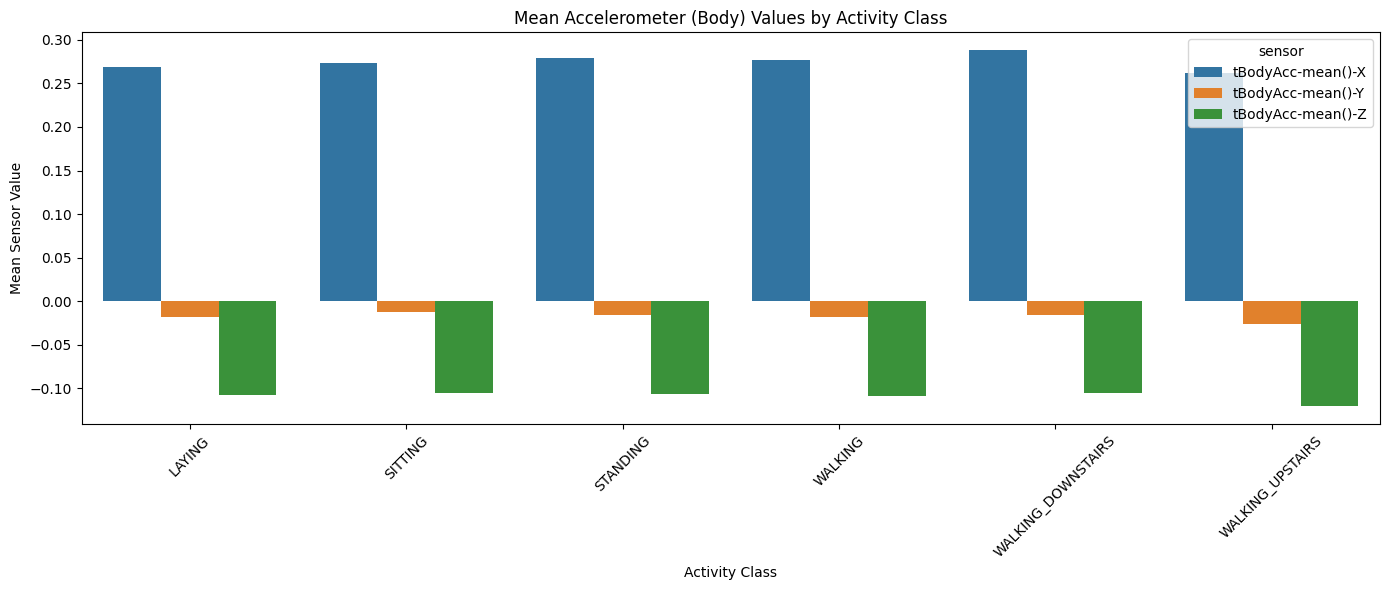

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

acc_cols = ['tBodyAcc-mean()-X', 'tBodyAcc-mean()-Y', 'tBodyAcc-mean()-Z']


mean_acc = full_data.groupby('class')[acc_cols].mean().reset_index()


mean_acc_melted = mean_acc.melt(id_vars='class', var_name='sensor', value_name='mean_value')


plt.figure(figsize=(14, 6))
sns.barplot(data=mean_acc_melted, x='class', y='mean_value', hue='sensor')
plt.xticks(rotation=45)
plt.title('Mean Accelerometer (Body) Values by Activity Class')
plt.ylabel('Mean Sensor Value')
plt.xlabel('Activity Class')
plt.tight_layout()
plt.show()


Interpretation of the Mean Accelerometer (Body) Values by Activity Class:

All activities show a consistent axis pattern:

1.tBodyAcc-mean()-X: Strongly positive, indicating dominant force or orientation in the X-direction (likely side-to-side or gravity-aligned).

tBodyAcc-mean()-Y: Slightly negative, suggesting mild motion or tilt in the forward/backward axis.

tBodyAcc-mean()-Z: Moderately negative, likely reflecting gravitational pull in a vertical orientation.

2.Walking, Walking Upstairs, and Walking Downstairs:

Have slightly more negative values in Z, indicating dynamic vertical movement (e.g., leg lifts or stair steps).

Show similar X and Y means to static activities, suggesting posture and direction remain mostly consistent.

3.Laying, Sitting, and Standing:

Display nearly identical acceleration profiles, with minimal variation across axes.

Indicates very little body motion, consistent with static postures.

4.tBodyAcc-mean()-X stands out as the dominant axis:

Uniformly high across all activities, possibly due to sensor orientation or body alignment during data collection.

5.Y and Z axes show more nuanced variation:

Y-axis: Mild differences between activities but consistently negative.

Z-axis: More negative during dynamic activities, indicating vertical motion or impact forces during steps.



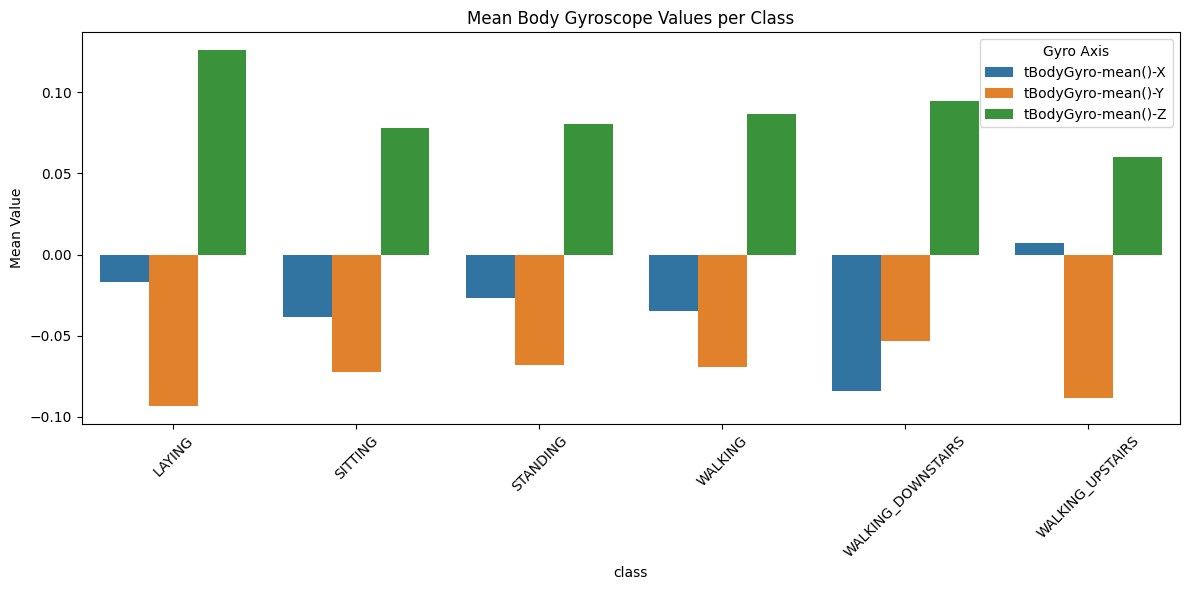

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns


gyro_cols = ['tBodyGyro-mean()-X', 'tBodyGyro-mean()-Y', 'tBodyGyro-mean()-Z']
mean_gyro = full_data.groupby('class')[gyro_cols].mean().reset_index()


gyro_melt = mean_gyro.melt(id_vars='class', var_name='Gyro Axis', value_name='Mean Value')

plt.figure(figsize=(12, 6))
sns.barplot(data=gyro_melt, x='class', y='Mean Value', hue='Gyro Axis')
plt.title('Mean Body Gyroscope Values per Class')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


Interpretation of the Mean Body Gyroscope Values per Activity Class:  
1.Dynamic activities like Walking, Walking Upstairs, and Walking Downstairs:

Exhibit stronger gyroscope responses across all axes, especially in Z and Y, reflecting multi-axis rotational body movement.

2.Static postures such as Sitting, Standing, and Laying:

Show less variation, but interestingly, Laying has a high Z-axis mean, possibly due to initial posture adjustment or residual rotation.


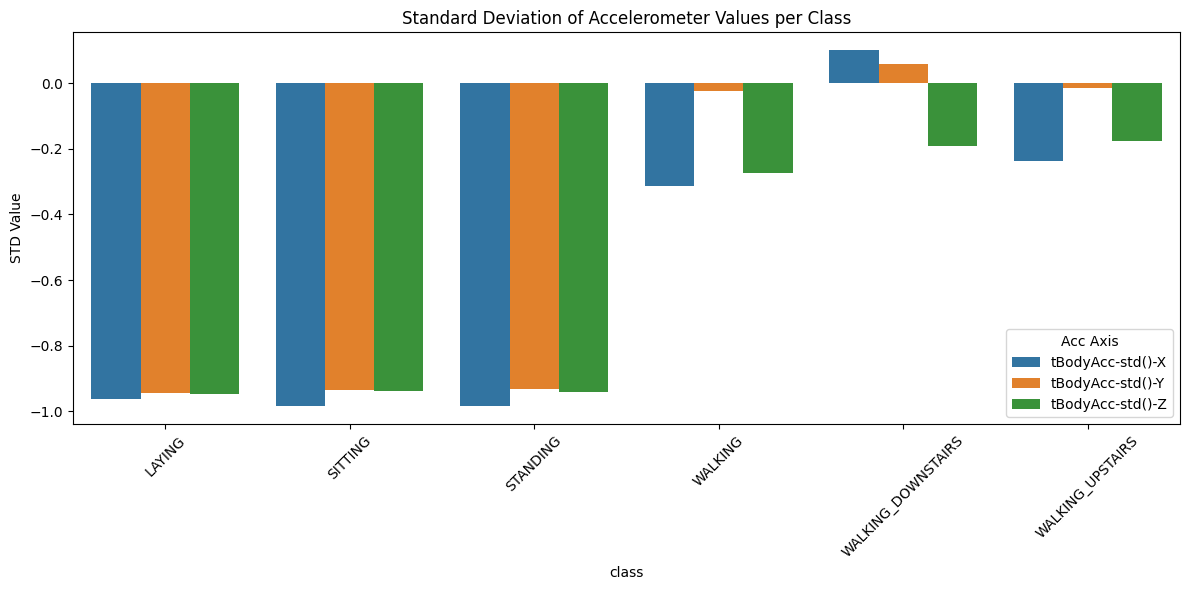

In [ ]:

acc_std_cols = ['tBodyAcc-std()-X', 'tBodyAcc-std()-Y', 'tBodyAcc-std()-Z']


mean_acc_std = full_data.groupby('class')[acc_std_cols].mean().reset_index()


acc_std_melt = mean_acc_std.melt(id_vars='class', var_name='Acc Axis', value_name='STD Value')


plt.figure(figsize=(12, 6))
sns.barplot(data=acc_std_melt, x='class', y='STD Value', hue='Acc Axis')
plt.title('Standard Deviation of Accelerometer Values per Class')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


Interpretation of the chart: Standard Deviation of Accelerometer Values per Class, following the same format as before:

1.Static activities – Laying, Sitting, and Standing:

All three axes (X, Y, Z) show high negative standard deviation values, close to -1, indicating very low variability in movement.

This suggests these activities involve minimal or no body acceleration—consistent with resting or stationary postures.

2.Dynamic activities – Walking, Walking Downstairs, and Walking Upstairs:

Show higher standard deviations across all axes, particularly:

tBodyAcc-std()-Z: noticeable increase during Walking Downstairs and Walking Upstairs, likely from vertical leg movements or bouncing.

tBodyAcc-std()-X: slightly positive in Walking Downstairs, indicating side-to-side acceleration variation from gait patterns or balance control.

This indicates greater variability in motion, typical of physically engaging tasks.

3.Walking Downstairs:

Unique in showing positive deviation in X-axis, unlike other activities.

Suggests increased lateral instability or sway while descending.

4.Overall trend:

Standard deviation is lowest (most negative) for non-movement tasks.

Dynamic tasks show greater spread in acceleration, especially in the Z-axis, confirming vertical movement complexity in walking activities.



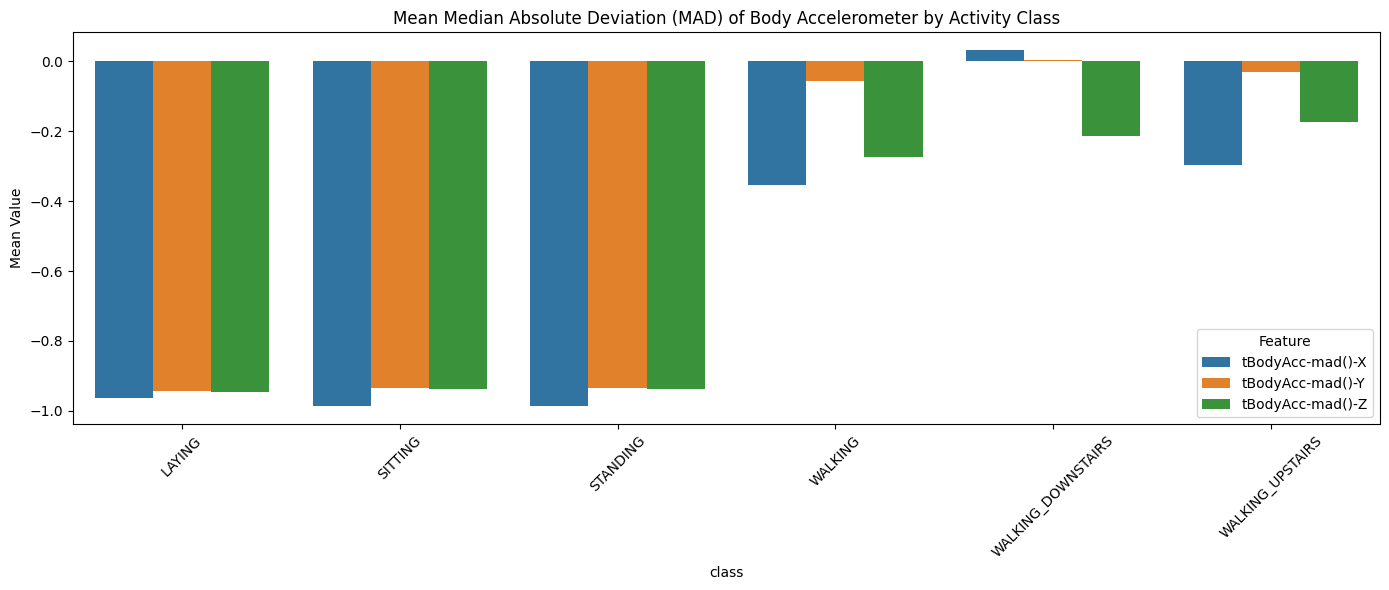

In [ ]:
mad_features = ['tBodyAcc-mad()-X', 'tBodyAcc-mad()-Y', 'tBodyAcc-mad()-Z']

mean_mad = full_data.groupby('class')[mad_features].mean().reset_index()
mean_mad_melted = mean_mad.melt(id_vars='class', var_name='Feature', value_name='Mean Value')

plt.figure(figsize=(14,6))
sns.barplot(x='class', y='Mean Value', hue='Feature', data=mean_mad_melted)
plt.xticks(rotation=45)
plt.title('Mean Median Absolute Deviation (MAD) of Body Accelerometer by Activity Class')
plt.tight_layout()
plt.show()


Interpretations of the plot titled "Mean Median Absolute Deviation (MAD) of Body Accelerometer by Activity Class":

1.Static Activities (Laying, Sitting, Standing):

Show consistently low MAD across all axes.

Highly stable with minimal body movement variance.

Very hard to distinguish among themselves using MAD alone.

2.Dynamic Activities:

Walking Downstairs shows highest MAD, especially on X-axis — indicating irregular, unbalanced motion.

Walking Upstairs follows closely with high variability in Z-axis (vertical) due to lifting motion.

Walking is moderate in terms of MAD — suggests controlled, rhythmic motion.

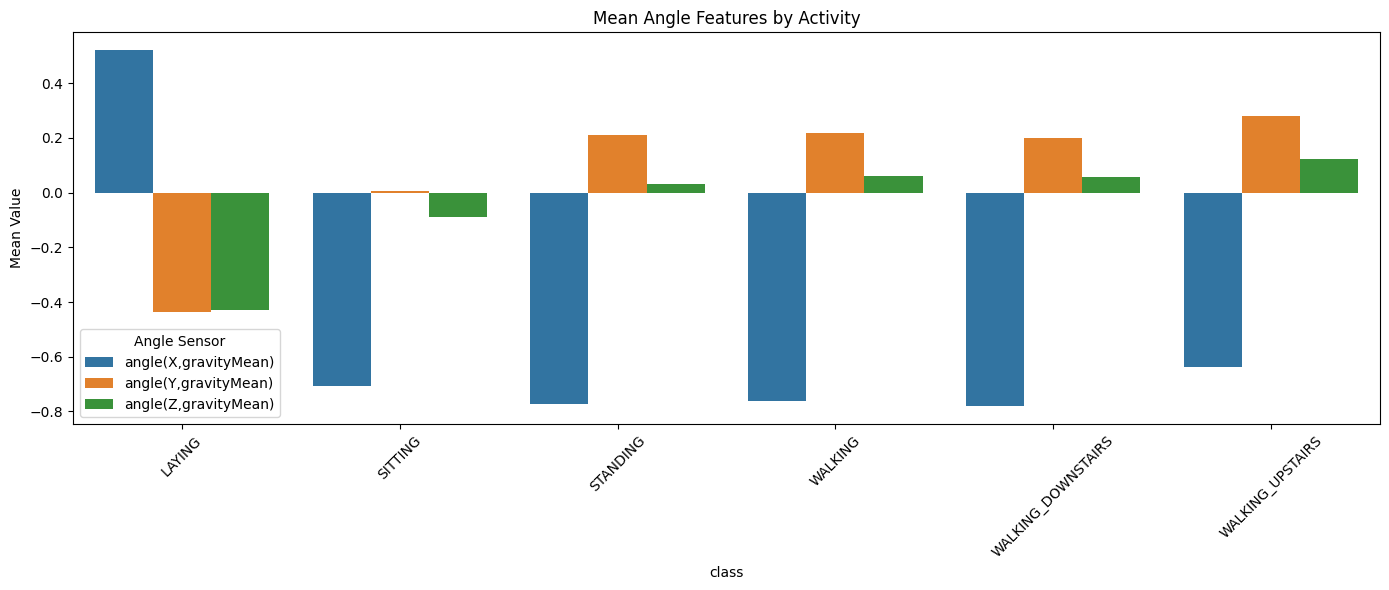

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


angle_cols = [
    'angle(X,gravityMean)',
    'angle(Y,gravityMean)',
    'angle(Z,gravityMean)'
]


class_col = 'class' if 'class' in df.columns else 'Activity'


mean_angles = full_data.groupby(class_col)[angle_cols].mean().reset_index()


angle_melted = mean_angles.melt(id_vars=class_col,
                                var_name='Angle Sensor',
                                value_name='Mean Value')

plt.figure(figsize=(14, 6))
sns.barplot(data=angle_melted, x=class_col, y='Mean Value', hue='Angle Sensor')
plt.title("Mean Angle Features by Activity")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


Interpretation of "Mean Angle Features by Activity" bar plot:  

1.X-angle is most positive for laying, most negative for standing, and progressively less negative for dynamic movements.

2.Y-angle increases with activity intensity, peaking during walking upstairs.

3.Z-angle rises with vertical exertion, being lowest for static postures and highest during stairs activity.

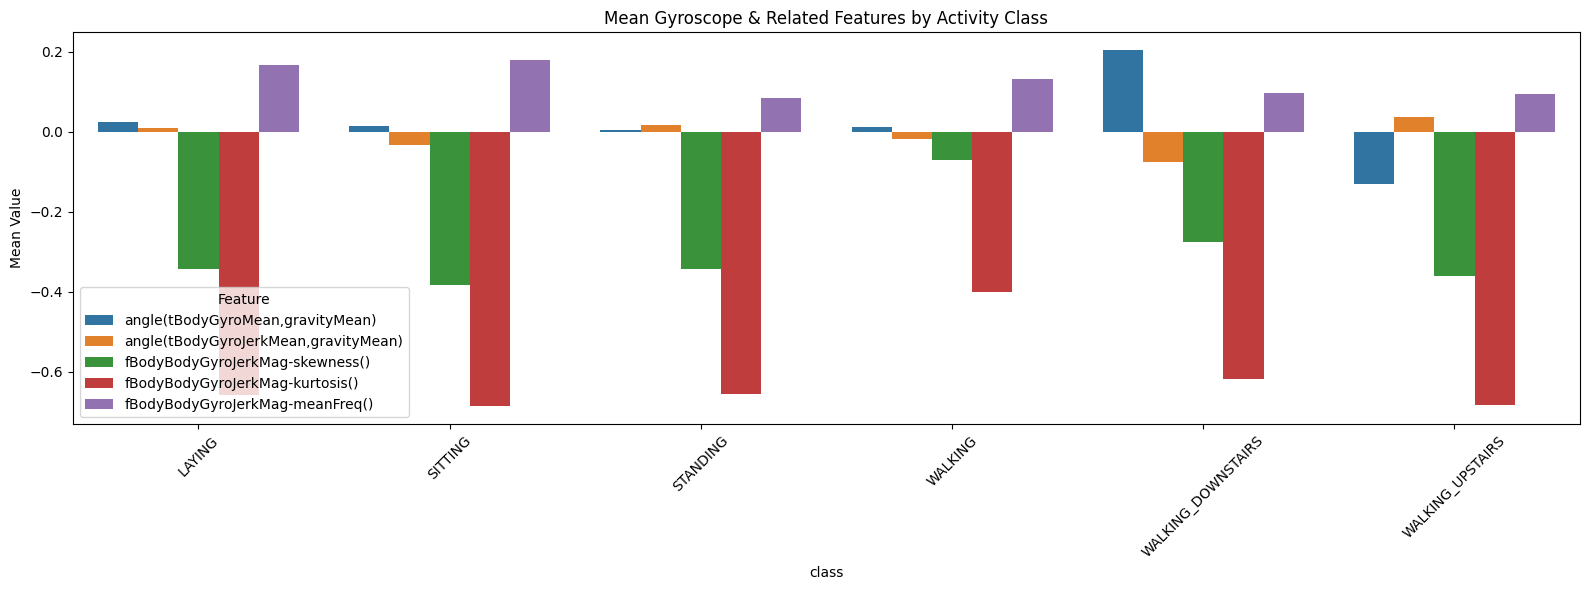

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt


gyro_features = [
    'angle(tBodyGyroMean,gravityMean)',
    'angle(tBodyGyroJerkMean,gravityMean)',
    'fBodyBodyGyroJerkMag-skewness()',
    'fBodyBodyGyroJerkMag-kurtosis()','fBodyBodyGyroJerkMag-meanFreq()'
]

class_col = 'class'

mean_gyro = full_data.groupby(class_col)[gyro_features].mean().reset_index()


mean_gyro_melted = mean_gyro.melt(id_vars=class_col, var_name='Feature', value_name='Mean Value')


plt.figure(figsize=(16,6))
sns.barplot(data=mean_gyro_melted, x=class_col, y='Mean Value', hue='Feature')
plt.xticks(rotation=45)
plt.title('Mean Gyroscope & Related Features by Activity Class')
plt.tight_layout()
plt.show()


Interpretation of the chart "Mean Gyroscope & Related Features by Activity Class":   
1.Walking Downstairs stands out with high angle, high skewness, and lowest kurtosis, suggesting frequent, irregular, but smoother angular movements.

2.Static activities (Laying, Sitting, Standing) show higher frequency components, but more symmetrical jerk distributions (less skew).



COMBINING DATASETS

Combining the most significant features obtained by ANOVA Test which were a prominent differentiating factor

In [ ]:

import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt


wisdm_cols = ['"XABSOLDEV"', '"YABSOLDEV"', '"ZABSOLDEV"', '"RESULTANT"']
mhealth_cols = ['acc_x', 'gyro_x', 'gyro_y']
uci_cols = ['fBodyAccJerk-entropy()-X', 'tGravityAcc-mean()-X', 'tBodyAcc-std()-X']

#Define activity label mapping
activity_map = {
    "Walking": "Walking", "WALKING": "Walking",
    "Walking Upstairs": "Upstairs", "WALKING_UPSTAIRS": "Upstairs", "Climbing stairs": "Upstairs",
    "Walking Downstairs": "Downstairs", "WALKING_DOWNSTAIRS": "Downstairs",
    "Sitting": "Sitting", "SITTING": "Sitting", "Sitting and relaxing": "Sitting",
    "Standing": "Standing", "STANDING": "Standing", "Standing still": "Standing",
    "LAYING": "Laying", "Lying down": "Laying",
    "Jogging": "Jogging", "RUNNING": "Jogging", "Running": "Jogging",
    "Jump front & back": "Jumping", "Cycling": "Cycling", "Waist bends forward": "Bending"
}



# Process WISDM dataframe
wisdm_df = df.copy()
wisdm_df['class'] = wisdm_df['class'].apply(lambda x: x.decode('utf-8') if isinstance(x, bytes) else x)
wisdm_df = wisdm_df.dropna(subset=['class'])
wisdm_df['class_name'] = wisdm_df['class'].map(activity_map)
wisdm_df = wisdm_df[wisdm_cols + ['class_name']]
wisdm_df.columns = ['feat1', 'feat2', 'feat3', 'feat4', 'class_name']
wisdm_df['source'] = 'WISDM'

# Prepare MHEALTH
mhealth_df = final_df.copy()
mhealth_df['class_name'] = mhealth_df['class_name'].map(activity_map)
mhealth_df = mhealth_df[mhealth_cols + ['class_name']]
mhealth_df.columns = ['feat1', 'feat2', 'feat3', 'class_name']
mhealth_df['feat4'] = 0  # Padding
mhealth_df['source'] = 'MHEALTH'

# Prepare UCI HAR
uci_df = full_data.copy()
uci_df['class_name'] = uci_df['class'].map(activity_map)
uci_df = uci_df[uci_cols + ['class_name']]
uci_df.columns = ['feat1', 'feat2', 'feat3', 'class_name']
uci_df['feat4'] = 0  # Padding
uci_df['source'] = 'UCI'

# Combine datasets
combined_df = pd.concat([wisdm_df, mhealth_df, uci_df], ignore_index=True)
combined_df = combined_df.dropna(subset=['class_name'])



/tmp/ipython-input-107-2641366707.py:43: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  mhealth_df['feat4'] = 0  # Padding
/tmp/ipython-input-107-2641366707.py:44: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  mhealth_df['source'] = 'MHEALTH'


# Use Standard Scaler and run Random Forest ML Model


🔍 Classification Report:
              precision    recall  f1-score   support

     Bending       0.96      0.99      0.97      5663
     Cycling       1.00      1.00      1.00      6144
  Downstairs       0.80      0.82      0.81       281
     Jogging       0.97      0.98      0.97     12611
     Jumping       0.95      0.83      0.88      2069
      Laying       1.00      0.99      1.00      6533
     Sitting       0.98      0.98      0.98      6526
    Standing       0.97      0.98      0.98      6540
    Upstairs       0.96      0.96      0.96      6453
     Walking       0.96      0.96      0.96      6894

    accuracy                           0.97     59714
   macro avg       0.95      0.95      0.95     59714
weighted avg       0.97      0.97      0.97     59714



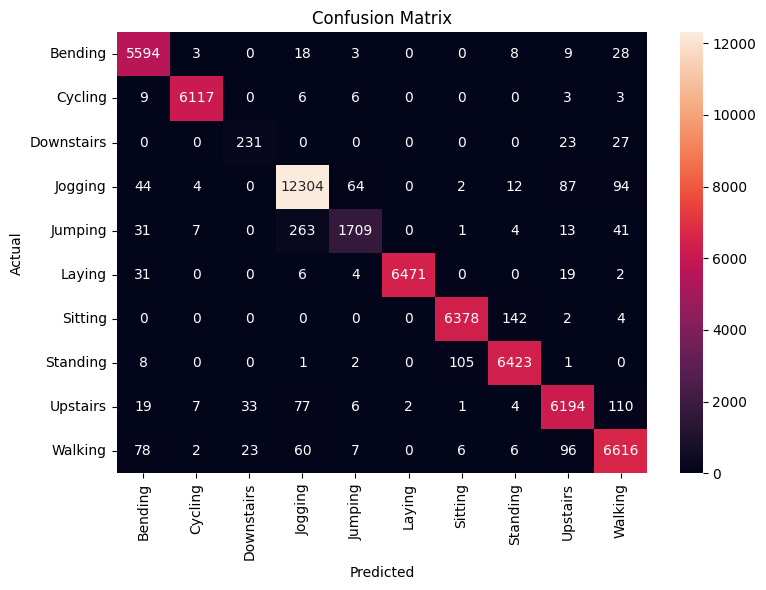

In [ ]:
#Standardize and encode
features = ['feat1', 'feat2', 'feat3', 'feat4']
scaler = StandardScaler()
combined_df[features] = scaler.fit_transform(combined_df[features])

le = LabelEncoder()
combined_df['label'] = le.fit_transform(combined_df['class_name'])

#Train-test split and model
X = combined_df[features]
y = combined_df['label']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

clf = RandomForestClassifier(n_estimators=100, random_state=42)
clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)

#Evaluation
print("\Classification Report:")
print(classification_report(y_test, y_pred, target_names=le.classes_))

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=le.classes_, yticklabels=le.classes_)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.tight_layout()
plt.show()


The above model demonstrates good accuracy for several activities but struggles with distinguishing between "Downstairs," "Jogging," and "Jumping," and has some difficulty with "Sitting" when compared to "Standing."

Random Forest Model with more ANOVA features

              precision    recall  f1-score   support

     Bending       0.84      0.92      0.88      5663
     Cycling       0.99      0.97      0.98      6144
  Downstairs       0.84      0.72      0.78       281
     Jogging       0.87      0.97      0.91     12611
     Jumping       0.94      0.12      0.21      2069
      Laying       1.00      1.00      1.00      6533
     Sitting       0.99      0.97      0.98      6526
    Standing       0.93      0.99      0.96      6540
    Upstairs       0.94      0.81      0.87      6453
     Walking       0.81      0.88      0.84      6894

    accuracy                           0.91     59714
   macro avg       0.91      0.83      0.84     59714
weighted avg       0.92      0.91      0.90     59714



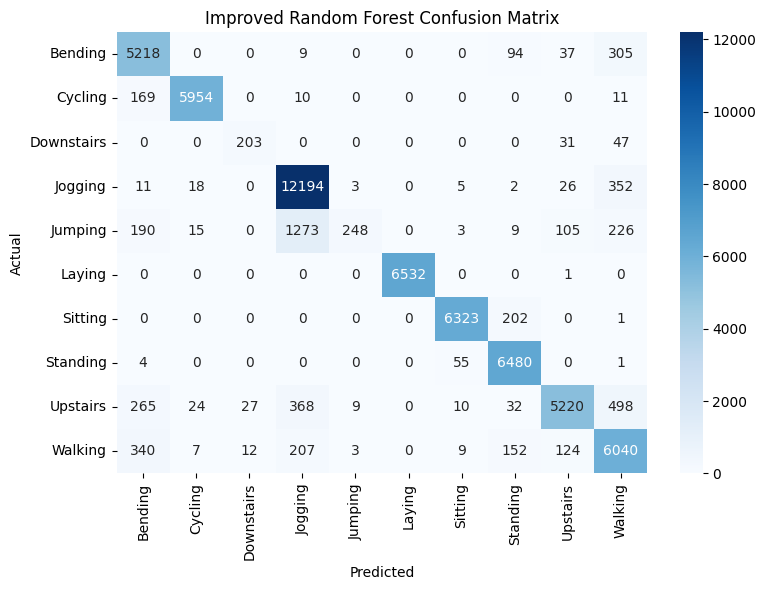

In [ ]:
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import train_test_split
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

activity_map = {
    "Walking": "Walking", "WALKING": "Walking",
    "Walking Upstairs": "Upstairs", "WALKING_UPSTAIRS": "Upstairs", "Climbing stairs": "Upstairs",
    "Walking Downstairs": "Downstairs", "WALKING_DOWNSTAIRS": "Downstairs",
    "Sitting": "Sitting", "SITTING": "Sitting", "Sitting and relaxing": "Sitting",
    "Standing": "Standing", "STANDING": "Standing", "Standing still": "Standing",
    "LAYING": "Laying", "Lying down": "Laying",
    "Jogging": "Jogging", "RUNNING": "Jogging", "Running": "Jogging",
    "Jump front & back": "Jumping", "Cycling": "Cycling", "Waist bends forward": "Bending"
}

df.columns = df.columns.str.replace('"', '', regex=False)
wisdm_cols = ['XABSOLDEV', 'YABSOLDEV', 'ZABSOLDEV', 'RESULTANT']
wisdm_df = df.copy()
wisdm_df['class'] = wisdm_df['class'].apply(lambda x: x.decode('utf-8') if isinstance(x, bytes) else x)
wisdm_df['class_name'] = wisdm_df['class'].map(activity_map)
wisdm_df = wisdm_df.dropna(subset=['class_name'])
wisdm_df = wisdm_df[wisdm_cols + ['class_name']]
wisdm_df.columns = ['feat1', 'feat2', 'feat3', 'feat4', 'class_name']
wisdm_df['acc_x'] = 0
wisdm_df['acc_y'] = 0
wisdm_df['gyro_x'] = 0
wisdm_df['gyro_y'] = 0
wisdm_df['tBodyAcc-std()-X'] = 0
wisdm_df['tGravityAcc-mean()-X'] = 0
wisdm_df['source'] = 'WISDM'

mhealth_df = final_df.copy()
mhealth_df['class_name'] = mhealth_df['class_name'].map(activity_map)
mhealth_df = mhealth_df.dropna(subset=['class_name'])
mhealth_df = mhealth_df[['acc_x', 'acc_y', 'gyro_x', 'gyro_y', 'class_name']]
mhealth_df['feat1'] = 0
mhealth_df['feat2'] = 0
mhealth_df['feat3'] = 0
mhealth_df['feat4'] = 0
mhealth_df['tBodyAcc-std()-X'] = 0
mhealth_df['tGravityAcc-mean()-X'] = 0
mhealth_df['source'] = 'MHEALTH'

uci_df = full_data.copy()
uci_df['class_name'] = uci_df['class'].map(activity_map)
uci_df = uci_df.dropna(subset=['class_name'])
uci_df = uci_df[['tBodyAcc-std()-X', 'tGravityAcc-mean()-X', 'class_name']]
uci_df['feat1'] = 0
uci_df['feat2'] = 0
uci_df['feat3'] = 0
uci_df['feat4'] = 0
uci_df['acc_x'] = 0
uci_df['acc_y'] = 0
uci_df['gyro_x'] = 0
uci_df['gyro_y'] = 0
uci_df['source'] = 'UCI'

combined_df = pd.concat([wisdm_df, mhealth_df, uci_df], ignore_index=True)
combined_df.dropna(subset=['class_name'], inplace=True)

feature_cols = ['feat1', 'feat2', 'feat3', 'feat4', 'acc_x', 'acc_y', 'gyro_x', 'gyro_y', 'tBodyAcc-std()-X', 'tGravityAcc-mean()-X']
scaler = StandardScaler()
combined_df[feature_cols] = scaler.fit_transform(combined_df[feature_cols])

le = LabelEncoder()
combined_df['label'] = le.fit_transform(combined_df['class_name'])

X = combined_df[feature_cols]
y = combined_df['label']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

clf = RandomForestClassifier(n_estimators=200, max_depth=12, random_state=42)
clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)

print(classification_report(y_test, y_pred, target_names=le.classes_))
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=le.classes_, yticklabels=le.classes_, cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Improved Random Forest Confusion Matrix")
plt.tight_layout()
plt.show()



The initial Random Forest model, with Standard Scaling, achieved 97% accuracy, excelling at most activities but struggling with "Downstairs" and "Jumping." The second model, also scaled but with more ANOVA-selected features, surprisingly saw its accuracy drop to 91%.This suggests that simply adding more statistically significant features doesn't guarantee better performance; it can introduce noise or redundancy, hindering the model's overall effectiveness.

# XGBoost Classifier

              precision    recall  f1-score   support

     Bending       0.83      0.91      0.87      5663
     Cycling       0.98      0.99      0.98      6144
  Downstairs       0.80      0.80      0.80       281
     Jogging       0.85      0.92      0.89     12611
     Jumping       0.77      0.18      0.29      2069
      Laying       1.00      0.99      0.99      6533
     Sitting       0.98      0.97      0.98      6526
    Standing       0.95      0.98      0.97      6540
    Upstairs       0.88      0.76      0.81      6453
     Walking       0.80      0.88      0.84      6894

    accuracy                           0.90     59714
   macro avg       0.88      0.84      0.84     59714
weighted avg       0.90      0.90      0.89     59714



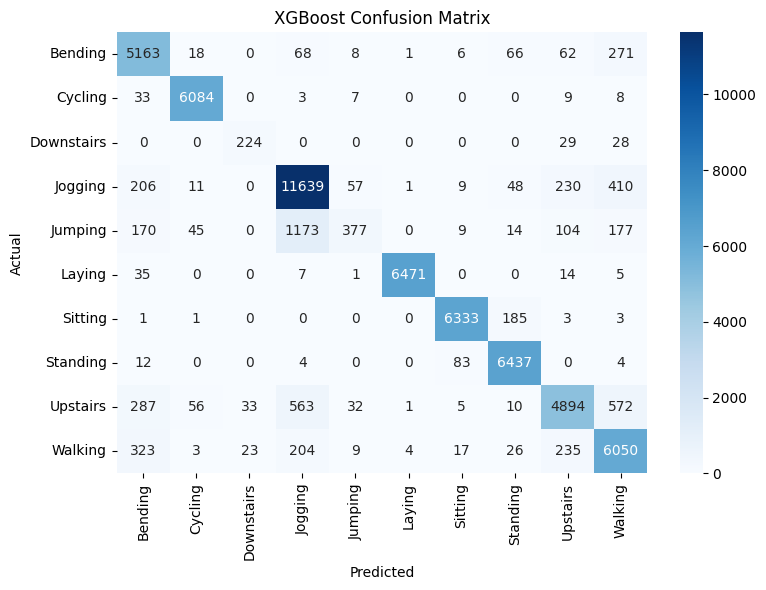

In [ ]:
!pip install xgboost -q
import xgboost as xgb
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

xgb_clf = xgb.XGBClassifier(n_estimators=200, learning_rate=0.1, max_depth=8, subsample=0.8, colsample_bytree=0.8, random_state=42, n_jobs=-1)
xgb_clf.fit(X_train, y_train)
y_pred = xgb_clf.predict(X_test)

print(classification_report(y_test, y_pred, target_names=le.classes_))
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=le.classes_, yticklabels=le.classes_, cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("XGBoost Confusion Matrix")
plt.tight_layout()
plt.show()


XG Boost model with more ANOVA features

/tmp/ipython-input-110-3331512966.py:40: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  mhealth_df['feat1'] = 0
/tmp/ipython-input-110-3331512966.py:41: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  mhealth_df['feat2'] = 0
/tmp/ipython-input-110-3331512966.py:42: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexi

              precision    recall  f1-score   support

     Bending       0.95      0.98      0.97      5663
     Cycling       0.99      1.00      0.99      6144
  Downstairs       0.79      0.78      0.79       281
     Jogging       0.91      0.97      0.94     12611
     Jumping       0.88      0.46      0.61      2069
      Laying       1.00      1.00      1.00      6533
     Sitting       0.99      0.97      0.98      6526
    Standing       0.97      0.99      0.98      6540
    Upstairs       0.95      0.89      0.92      6453
     Walking       0.90      0.94      0.92      6894

    accuracy                           0.95     59714
   macro avg       0.93      0.90      0.91     59714
weighted avg       0.95      0.95      0.95     59714



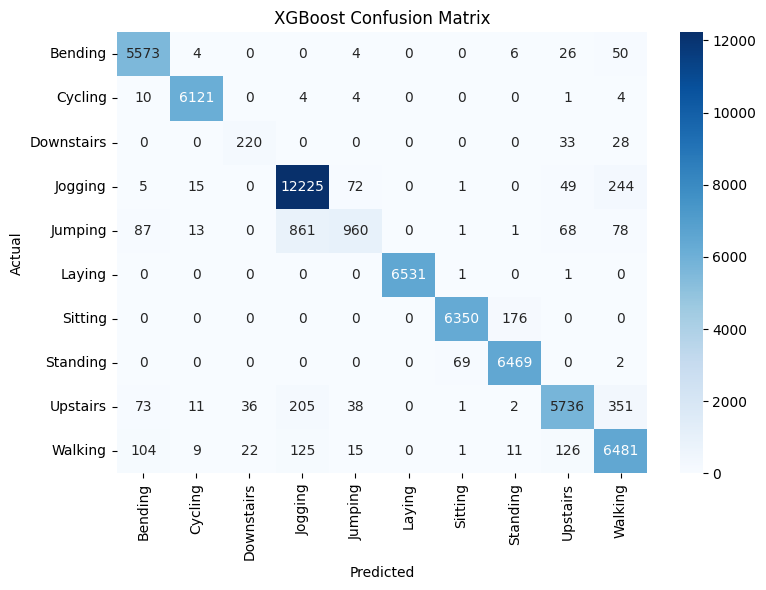

In [ ]:

import xgboost as xgb
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

activity_map = {
    "Walking": "Walking", "WALKING": "Walking",
    "Walking Upstairs": "Upstairs", "WALKING_UPSTAIRS": "Upstairs", "Climbing stairs": "Upstairs",
    "Walking Downstairs": "Downstairs", "WALKING_DOWNSTAIRS": "Downstairs",
    "Sitting": "Sitting", "SITTING": "Sitting", "Sitting and relaxing": "Sitting",
    "Standing": "Standing", "STANDING": "Standing", "Standing still": "Standing",
    "LAYING": "Laying", "Lying down": "Laying",
    "Jogging": "Jogging", "RUNNING": "Jogging", "Running": "Jogging",
    "Jump front & back": "Jumping", "Cycling": "Cycling", "Waist bends forward": "Bending"
}

df.columns = df.columns.str.replace('"', '', regex=False)
wisdm_cols = ['XABSOLDEV', 'YABSOLDEV', 'ZABSOLDEV', 'RESULTANT']
wisdm_df = df.copy()
wisdm_df['class'] = wisdm_df['class'].apply(lambda x: x.decode('utf-8') if isinstance(x, bytes) else x)
wisdm_df['class_name'] = wisdm_df['class'].map(activity_map)
wisdm_df = wisdm_df.dropna(subset=['class_name'])
wisdm_df = wisdm_df[wisdm_cols + ['class_name']]
wisdm_df.columns = ['feat1', 'feat2', 'feat3', 'feat4', 'class_name']
wisdm_df['acc_x'] = 0
wisdm_df['acc_y'] = 0
wisdm_df['gyro_x'] = 0
wisdm_df['gyro_y'] = 0
wisdm_df['tBodyAcc-std()-X'] = 0
wisdm_df['tGravityAcc-mean()-X'] = 0
wisdm_df['source'] = 'WISDM'

mhealth_df = final_df.copy()
mhealth_df['class_name'] = mhealth_df['class_name'].map(activity_map)
mhealth_df = mhealth_df.dropna(subset=['class_name'])
mhealth_df = mhealth_df[['acc_x', 'acc_y', 'gyro_x', 'gyro_y', 'class_name']]
mhealth_df['feat1'] = 0
mhealth_df['feat2'] = 0
mhealth_df['feat3'] = 0
mhealth_df['feat4'] = 0
mhealth_df['tBodyAcc-std()-X'] = 0
mhealth_df['tGravityAcc-mean()-X'] = 0
mhealth_df['source'] = 'MHEALTH'

uci_df = full_data.copy()
uci_df['class_name'] = uci_df['class'].map(activity_map)
uci_df = uci_df.dropna(subset=['class_name'])
uci_df = uci_df[['tBodyAcc-std()-X', 'tGravityAcc-mean()-X', 'class_name']]
uci_df['feat1'] = 0
uci_df['feat2'] = 0
uci_df['feat3'] = 0
uci_df['feat4'] = 0
uci_df['acc_x'] = 0
uci_df['acc_y'] = 0
uci_df['gyro_x'] = 0
uci_df['gyro_y'] = 0
uci_df['source'] = 'UCI'

combined_df = pd.concat([wisdm_df, mhealth_df, uci_df], ignore_index=True)
combined_df.dropna(subset=['class_name'], inplace=True)

feature_cols = ['feat1', 'feat2', 'feat3', 'feat4', 'acc_x', 'acc_y', 'gyro_x', 'gyro_y', 'tBodyAcc-std()-X', 'tGravityAcc-mean()-X']
scaler = StandardScaler()
combined_df[feature_cols] = scaler.fit_transform(combined_df[feature_cols])

le = LabelEncoder()
combined_df['label'] = le.fit_transform(combined_df['class_name'])

X = combined_df[feature_cols]
y = combined_df['label']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

xgb_clf = xgb.XGBClassifier(n_estimators=300, learning_rate=0.05, max_depth=8, subsample=0.9, colsample_bytree=0.8, random_state=42, n_jobs=-1)
xgb_clf.fit(X_train, y_train)
y_pred = xgb_clf.predict(X_test)

print(classification_report(y_test, y_pred, target_names=le.classes_))
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=le.classes_, yticklabels=le.classes_, cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("XGBoost Confusion Matrix")
plt.tight_layout()
plt.show()


 XGBoost model with more ANOVA-selected features (0.95 accuracy) significantly outperforms the one with fewer features (0.90 accuracy). The additional, carefully chosen features led to a substantial improvement in overall accuracy and in the classification of most activities, indicating that the feature engineering step was highly beneficial for this model